# Đánh giá mô hình Abalone

Notebook này thực hiện bước `Assess Model` trên tập kiểm tra (`test data`). Mục tiêu là đánh giá năng lực tổng quát hóa của các mô hình baseline sau khi đã hoàn tất huấn luyện và kiểm tra chéo ở notebook 03.

## 1. Mục tiêu của bước đánh giá

- Nạp lại các mô hình baseline đã được huấn luyện trên toàn bộ tập train.
- Chạy dự đoán trên tập test tương ứng với từng phiên bản dữ liệu.
- Tính các metric `MSE`, `RMSE`, `RSE`, `MAE` trên test set.
- So sánh kết quả `CV` và `Test` để quan sát độ ổn định của mô hình.
- Xác định các mô hình tốt nhất theo từng thang đo và tạo biểu đồ phục vụ báo cáo.

## 2. Chuẩn bị thư viện

In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import learning_curve
from sklearn.neural_network import MLPRegressor

# Dung helper metric va ve bieu do tu src/
from src.models.evaluate import evaluate_regression_metrics
from src.visualization.plot_results import plot_prediction_scatter, plot_residual_scatter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)


## 3. Load dữ liệu test và kết quả baseline

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed' # Đường dẫn đến thư mục chứa dữ liệu đã được xử lý, bao gồm các file CSV đã được one-hot encoding, label encoding và chuẩn hóa.
MODELS_DIR = PROJECT_ROOT / 'outputs' / 'models' # Đường dẫn đến thư mục chứa các mô hình đã được huấn luyện, bao gồm các file .joblib lưu trữ mô hình và file .json lưu trữ thông tin về các mô hình.
METRICS_DIR = PROJECT_ROOT / 'outputs' / 'metrics' # Đường dẫn đến thư mục chứa các metric đánh giá mô hình.
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures' # Đường dẫn đến thư mục chứa các hình ảnh trực quan hóa kết quả.

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

test_encoded_df = pd.read_csv(PROCESSED_DIR / 'abalone_test_encoded.csv')
test_standard_df = pd.read_csv(PROCESSED_DIR / 'abalone_test_standard.csv')
baseline_cv_results = pd.read_csv(METRICS_DIR / 'baseline_cv_results.csv')

display(test_encoded_df.head())
display(baseline_cv_results.head())

,Sex_F,Sex_I,Sex_M,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,0.0,0.0,1.0,0.605,0.455,0.160,1.1035,0.4210,0.3015,0.325,9
1,0.0,0.0,1.0,0.590,0.440,0.150,0.8725,0.3870,0.2150,0.245,8
2,1.0,0.0,0.0,0.560,0.445,0.195,0.9810,0.3050,0.2245,0.335,16
3,1.0,0.0,0.0,0.635,0.490,0.170,1.2615,0.5385,0.2665,0.380,9
4,0.0,0.0,1.0,0.475,0.385,0.145,0.6175,0.2350,0.1080,0.215,14


,model,dataset_version,mse,rmse,rse,mae,execution_time_sec
0,GradientBoostingRegressor,encoded_only,4.716286,2.171701,0.449745,1.530359,1.325615
1,SVR,standard_scaled,4.754919,2.180578,0.453429,1.482348,1.404382
2,MLPRegressor,standard_scaled,4.904670,2.214649,0.467710,1.497876,7.432869
3,RandomForestRegressor,encoded_only,4.927610,2.219822,0.469897,1.564047,2.342175
4,LinearRegression,standard_scaled,5.117518,2.262193,0.488007,1.602625,5.268527


## 4. Chuẩn bị tập test theo từng phiên bản dữ liệu

In [3]:
target_col = 'Rings'

X_test_encoded = test_encoded_df.drop(columns=[target_col])
y_test_encoded = test_encoded_df[target_col]

X_test_standard = test_standard_df.drop(columns=[target_col])
y_test_standard = test_standard_df[target_col]

test_datasets = {
    'encoded_only': (X_test_encoded, y_test_encoded),
    'standard_scaled': (X_test_standard, y_test_standard),
}

for name, (X_part, y_part) in test_datasets.items():
    print(name, X_part.shape, y_part.shape)

encoded_only (1254, 10) (1254,)
standard_scaled (1254, 10) (1254,)


## 5. Hàm metric và hàm đánh giá

In [4]:
# Dung evaluate_regression_metrics() tu src/models/evaluate.py
def evaluate_saved_model(model_name):
    artifact = joblib.load(MODELS_DIR / f'baseline_{model_name}.joblib')
    model = artifact['model']
    dataset_version = artifact['dataset_version']
    feature_names = artifact['feature_names']

    X_test_current, y_test_current = test_datasets[dataset_version]
    X_test_current = X_test_current[feature_names]

    start_time = time.perf_counter()
    y_pred = model.predict(X_test_current)
    inference_time = time.perf_counter() - start_time

    metrics = evaluate_regression_metrics(y_test_current, y_pred)

    return {
        'model': model_name,
        'dataset_version': dataset_version,
        'y_true': y_test_current,
        'y_pred': y_pred,
        'inference_time_sec': inference_time,
        **metrics,
    }


## 6. Đánh giá tất cả mô hình trên tập test

In [5]:
model_names = baseline_cv_results['model'].tolist()
test_results = []
test_predictions = pd.DataFrame({'y_true': y_test_encoded.reset_index(drop=True)})
full_test_outputs = {}

# Đánh giá tất cả các mô hình đã lưu và thu thập kết quả vào test_results và test_predictions. 
# Kết quả đánh giá được lưu trữ trong full_test_outputs để sử dụng cho các phân tích và trực quan 
# hóa sau này. Cuối cùng, kết quả được chuyển đổi thành DataFrame và hiển thị dưới dạng bảng, sắp xếp 
# theo RMSE để dễ dàng so sánh hiệu suất giữa các mô hình.
for model_name in model_names:
    result = evaluate_saved_model(model_name)
    full_test_outputs[model_name] = result # Lưu kết quả đánh giá của từng mô hình vào dictionary full_test_outputs với tên mô hình làm key và kết quả đánh giá làm value.
    test_results.append(
        {
            'model': result['model'],
            'dataset_version': result['dataset_version'],
            'mse_test': result['mse'],
            'rmse_test': result['rmse'],
            'rse_test': result['rse'],
            'mae_test': result['mae'],
            'inference_time_sec': result['inference_time_sec'],
        }
    )
    test_predictions[model_name] = pd.Series(result['y_pred']).values

test_results_df = pd.DataFrame(test_results).sort_values(by='rmse_test', ascending=True).reset_index(drop=True)
display(test_results_df.round(4))

,model,dataset_version,mse_test,rmse_test,rse_test,mae_test,inference_time_sec
0,MLPRegressor,standard_scaled,4.3976,2.0970,0.4331,1.4871,0.0015
1,SVR,standard_scaled,4.6694,2.1609,0.4598,1.4914,0.3976
2,GradientBoostingRegressor,encoded_only,4.7523,2.1800,0.4680,1.5400,0.0045
3,RidgeRegression,standard_scaled,4.7757,2.1853,0.4703,1.5829,0.0019
4,LinearRegression,standard_scaled,4.7848,2.1874,0.4712,1.5832,0.0009
5,SGDRegressor,standard_scaled,4.8111,2.1934,0.4738,1.5855,0.0013
6,RandomForestRegressor,encoded_only,4.8165,2.1946,0.4743,1.5433,0.0453
7,LinearSVR,standard_scaled,4.8724,2.2074,0.4798,1.5363,0.0014
8,KNeighborsRegressor,standard_scaled,5.0457,2.2463,0.4969,1.5914,0.0191
9,DecisionTreeRegressor,encoded_only,8.9179,2.9863,0.8782,2.0678,0.0017


## 7. So sánh kết quả CV và Test

In [6]:
comparison_df = baseline_cv_results.merge(test_results_df, on=['model', 'dataset_version'], how='left')
comparison_df['rmse_gap'] = comparison_df['rmse_test'] - comparison_df['rmse']
comparison_df['mae_gap'] = comparison_df['mae_test'] - comparison_df['mae']
comparison_df = comparison_df.sort_values(by='rmse_test', ascending=True).reset_index(drop=True)

display(comparison_df.round(4))

,model,dataset_version,mse,rmse,rse,mae,execution_time_sec,mse_test,rmse_test,rse_test,mae_test,inference_time_sec,rmse_gap,mae_gap
0,MLPRegressor,standard_scaled,4.9047,2.2146,0.4677,1.4979,7.4329,4.3976,2.0970,0.4331,1.4871,0.0015,-0.1176,-0.0108
1,SVR,standard_scaled,4.7549,2.1806,0.4534,1.4823,1.4044,4.6694,2.1609,0.4598,1.4914,0.3976,-0.0197,0.0090
2,GradientBoostingRegressor,encoded_only,4.7163,2.1717,0.4497,1.5304,1.3256,4.7523,2.1800,0.4680,1.5400,0.0045,0.0083,0.0096
3,RidgeRegression,standard_scaled,5.1189,2.2625,0.4881,1.6020,0.0295,4.7757,2.1853,0.4703,1.5829,0.0019,-0.0772,-0.0191
4,LinearRegression,standard_scaled,5.1175,2.2622,0.4880,1.6026,5.2685,4.7848,2.1874,0.4712,1.5832,0.0009,-0.0748,-0.0194
5,SGDRegressor,standard_scaled,5.2445,2.2901,0.5001,1.6114,0.0493,4.8111,2.1934,0.4738,1.5855,0.0013,-0.0967,-0.0258
6,RandomForestRegressor,encoded_only,4.9276,2.2198,0.4699,1.5640,2.3422,4.8165,2.1946,0.4743,1.5433,0.0453,-0.0252,-0.0207
7,LinearSVR,standard_scaled,5.2501,2.2913,0.5007,1.5672,0.0466,4.8724,2.2074,0.4798,1.5363,0.0014,-0.0840,-0.0309
8,KNeighborsRegressor,standard_scaled,5.4723,2.3393,0.5218,1.6213,3.4916,5.0457,2.2463,0.4969,1.5914,0.0191,-0.0930,-0.0299
9,DecisionTreeRegressor,encoded_only,9.1150,3.0191,0.8692,2.0859,0.1312,8.9179,2.9863,0.8782,2.0678,0.0017,-0.0328,-0.0181


## 8. Chọn 2 mô hình tốt nhất theo từng metric

In [7]:
top2_rmse = comparison_df.nsmallest(2, 'rmse_test')[['model', 'rmse_test', 'dataset_version']]
top2_mae = comparison_df.nsmallest(2, 'mae_test')[['model', 'mae_test', 'dataset_version']]
top2_mse = comparison_df.nsmallest(2, 'mse_test')[['model', 'mse_test', 'dataset_version']]
top2_rse = comparison_df.nsmallest(2, 'rse_test')[['model', 'rse_test', 'dataset_version']]

print('Top 2 theo RMSE trên test:')
display(top2_rmse.round(4))
print('Top 2 theo MAE trên test:')
display(top2_mae.round(4))
print('Top 2 theo MSE trên test:')
display(top2_mse.round(4))
print('Top 2 theo RSE trên test:')
display(top2_rse.round(4))

Top 2 theo RMSE trên test:


,model,rmse_test,dataset_version
0,MLPRegressor,2.0970,standard_scaled
1,SVR,2.1609,standard_scaled


Top 2 theo MAE trên test:


,model,mae_test,dataset_version
0,MLPRegressor,1.4871,standard_scaled
1,SVR,1.4914,standard_scaled


Top 2 theo MSE trên test:


,model,mse_test,dataset_version
0,MLPRegressor,4.3976,standard_scaled
1,SVR,4.6694,standard_scaled


Top 2 theo RSE trên test:


,model,rse_test,dataset_version
0,MLPRegressor,0.4331,standard_scaled
1,SVR,0.4598,standard_scaled


## 9. Biểu đồ so sánh các mô hình trên test set

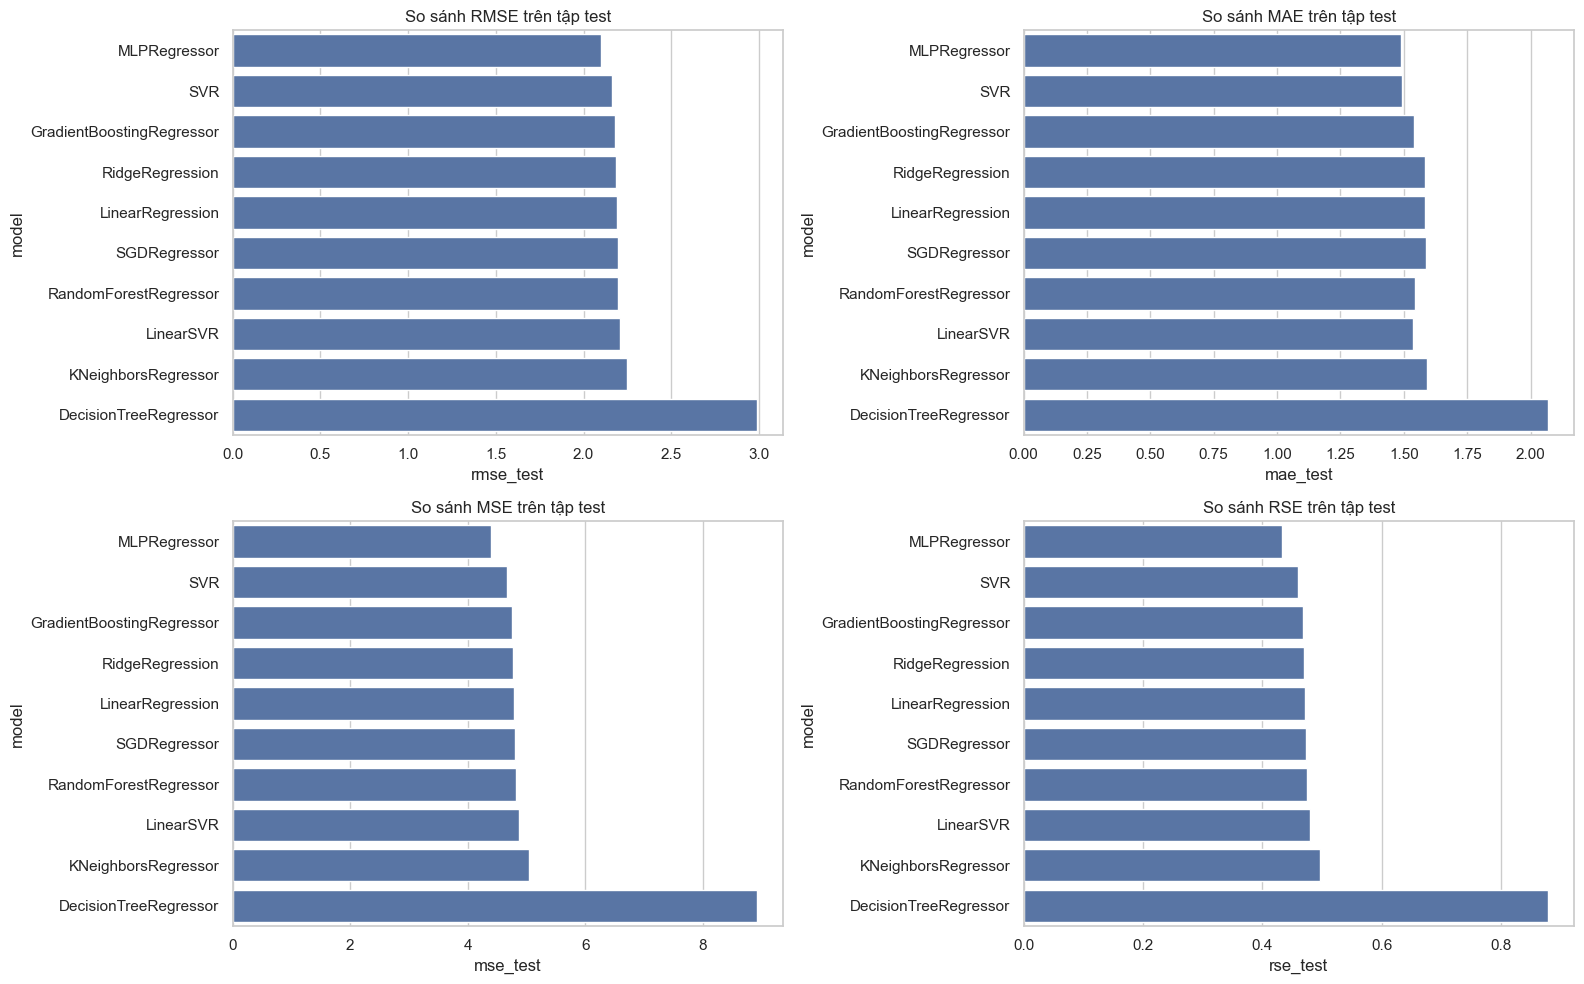

In [8]:
plot_df = comparison_df.sort_values('rmse_test', ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.barplot(data=plot_df, x='rmse_test', y='model', ax=axes[0, 0])
axes[0, 0].set_title('So sánh RMSE trên tập test')

sns.barplot(data=plot_df, x='mae_test', y='model', ax=axes[0, 1])
axes[0, 1].set_title('So sánh MAE trên tập test')

sns.barplot(data=plot_df, x='mse_test', y='model', ax=axes[1, 0])
axes[1, 0].set_title('So sánh MSE trên tập test')

sns.barplot(data=plot_df, x='rse_test', y='model', ax=axes[1, 1])
axes[1, 1].set_title('So sánh RSE trên tập test')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'test_metric_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Actual vs Predicted cho 2 mô hình tốt nhất theo RMSE

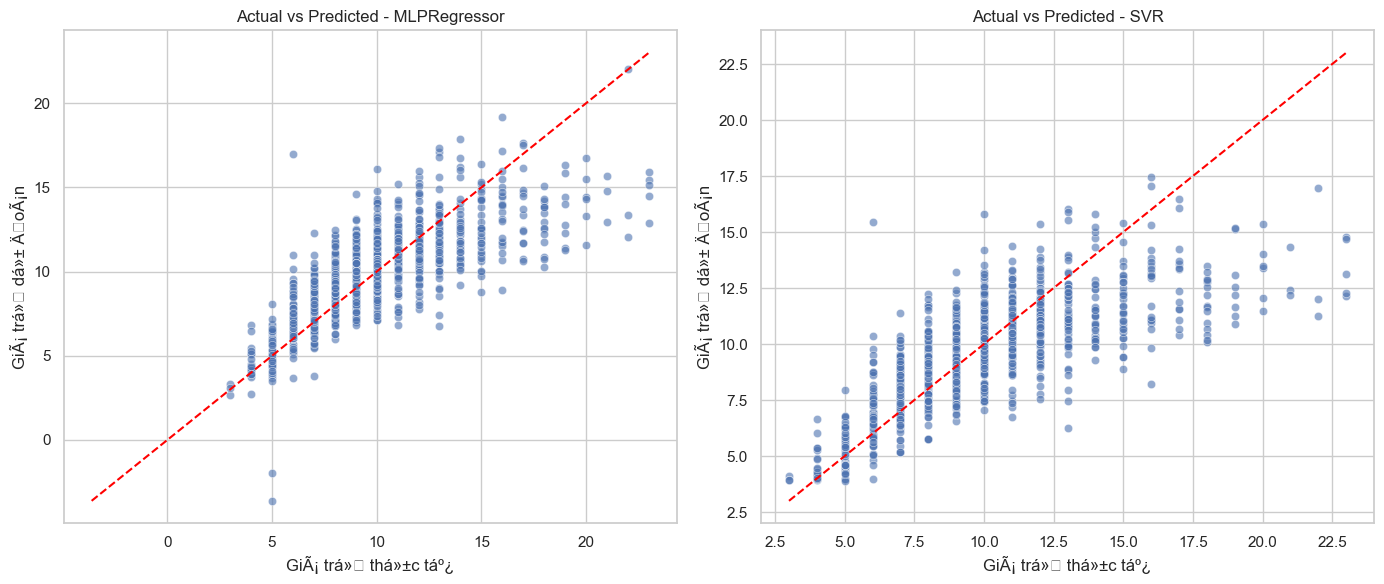

In [9]:
best_models_by_rmse = top2_rmse['model'].tolist()

fig, axes = plt.subplots(1, len(best_models_by_rmse), figsize=(7 * len(best_models_by_rmse), 6))
if len(best_models_by_rmse) == 1:
    axes = [axes]

for ax, model_name in zip(axes, best_models_by_rmse):
    y_true = full_test_outputs[model_name]['y_true']
    y_pred = full_test_outputs[model_name]['y_pred']
    # Dùng plot_prediction_scatter() từ src/visualization/plot_results.py
    plot_prediction_scatter(y_true, y_pred, model_name=model_name, ax=ax)
    ax.set_xlabel('Giá trị thực tế')
    ax.set_ylabel('Giá trị dự đoán')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'actual_vs_predicted_top2_rmse.png', dpi=300, bbox_inches='tight')
plt.show()


## 11. Residual plot cho 2 mô hình tốt nhất theo RMSE

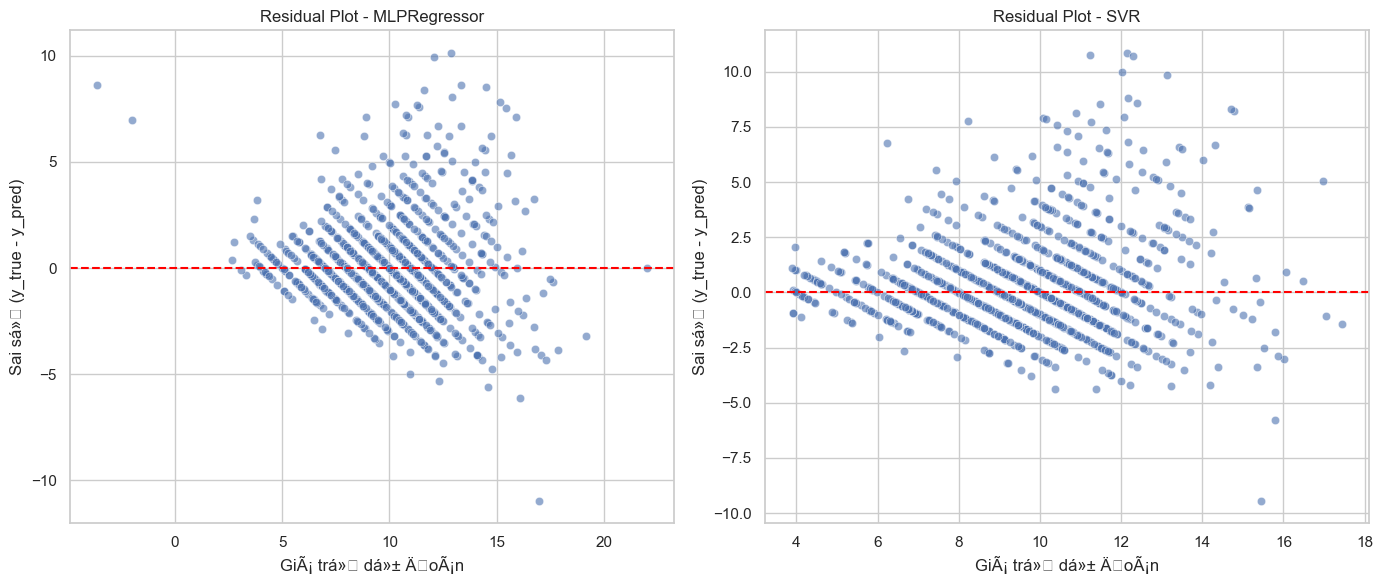

In [10]:
fig, axes = plt.subplots(1, len(best_models_by_rmse), figsize=(7 * len(best_models_by_rmse), 6))
if len(best_models_by_rmse) == 1:
    axes = [axes]

for ax, model_name in zip(axes, best_models_by_rmse):
    y_true = full_test_outputs[model_name]['y_true']
    y_pred = full_test_outputs[model_name]['y_pred']
    # Dùng plot_residual_scatter() từ src/visualization/plot_results.py
    plot_residual_scatter(y_true, y_pred, model_name=model_name, ax=ax)
    ax.set_xlabel('Giá trị dự đoán')
    ax.set_ylabel('Sai số (y_true - y_pred)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'residual_plot_top2_rmse.png', dpi=300, bbox_inches='tight')
plt.show()


## 12. Lưu kết quả bước đánh giá

In [11]:
test_results_df.to_csv(METRICS_DIR / 'baseline_test_results.csv', index=False)
comparison_df.to_csv(METRICS_DIR / 'baseline_cv_vs_test_results.csv', index=False)
test_predictions.to_csv(METRICS_DIR / 'baseline_test_predictions.csv', index=False)

evaluation_metadata = {
    'test_results_file': 'outputs/metrics/baseline_test_results.csv',
    'comparison_file': 'outputs/metrics/baseline_cv_vs_test_results.csv',
    'predictions_file': 'outputs/metrics/baseline_test_predictions.csv',
    'saved_figures': [
        'outputs/figures/test_metric_comparison.png',
        'outputs/figures/actual_vs_predicted_top2_rmse.png',
        'outputs/figures/residual_plot_top2_rmse.png',
        'outputs/figures/learning_curve_mlp_standard.png'
    ]
}

with open(METRICS_DIR / 'baseline_evaluation_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(evaluation_metadata, f, ensure_ascii=False, indent=2)

print('Đã lưu toàn bộ kết quả đánh giá trên tập test.')

Đã lưu toàn bộ kết quả đánh giá trên tập test.


## 13. Kết luận bước đánh giá

- Bước đánh giá trên tập test cho phép kiểm tra năng lực tổng quát hóa thật sự của các mô hình baseline.
- So sánh giữa `CV` và `Test` giúp phát hiện mô hình nào ổn định hơn và mô hình nào có dấu hiệu kém bền vững khi ra dữ liệu chưa thấy.
- Hai mô hình tốt nhất theo `RMSE` và `MAE` sẽ là ứng viên mạnh nhất để đi vào bước tối ưu hóa ở notebook 05.
- Các bảng số liệu và biểu đồ trong notebook này đã được lưu để dùng lại trực tiếp trong báo cáo và slide.

In [12]:
# Top 2 mô hình theo Execution Time (CV + fit) và Inference Time trên test

top2_execution = comparison_df.nsmallest(2, 'execution_time_sec')[['model', 'execution_time_sec', 'dataset_version']]
top2_inference = comparison_df.nsmallest(2, 'inference_time_sec')[['model', 'inference_time_sec', 'dataset_version']]

print('Top 2 theo Execution Time (CV + fit, giây):')
display(top2_execution.round(4))

print('Top 2 theo Inference Time trên test (giây):')
display(top2_inference.round(4))

Top 2 theo Execution Time (CV + fit, giây):


,model,execution_time_sec,dataset_version
3,RidgeRegression,0.0295,standard_scaled
7,LinearSVR,0.0466,standard_scaled


Top 2 theo Inference Time trên test (giây):


,model,inference_time_sec,dataset_version
4,LinearRegression,0.0009,standard_scaled
5,SGDRegressor,0.0013,standard_scaled


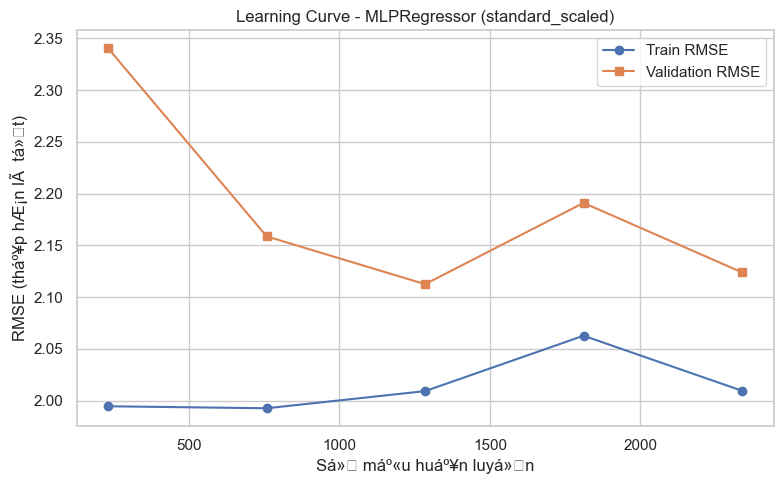

In [13]:
target_col = 'Rings'
train_standard_df = pd.read_csv(PROCESSED_DIR / 'abalone_train_standard.csv')

X = train_standard_df.drop(columns=[target_col])
y = train_standard_df[target_col]

estimator = MLPRegressor(random_state=42, max_iter=1000)

train_sizes, train_scores, val_scores = learning_curve(
    estimator,
    X,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    shuffle=True,
    random_state=42,
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, marker='o', label='Train RMSE')
plt.plot(train_sizes, val_rmse, marker='s', label='Validation RMSE')
plt.xlabel('Số mẫu huấn luyện')
plt.ylabel('RMSE (thấp hơn là tốt)')
plt.title('Learning Curve - MLPRegressor (standard_scaled)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'learning_curve_mlp_standard.png', dpi=300, bbox_inches='tight')
plt.show()
